In [1]:
import yfinance as yf
import pandas as pd

df = yf.download("RELIANCE.NS", start="2015-01-01", end="2024-01-01")    # # Download stock data (Reliance)

print(df.head())

[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open      Volume
Ticker     RELIANCE.NS RELIANCE.NS RELIANCE.NS RELIANCE.NS RELIANCE.NS
Date                                                                  
2015-01-01  189.999832  190.877186  189.090381  189.657461     2963643
2015-01-02  189.496948  191.743828  189.229471  190.042616     7331366
2015-01-05  187.421265  190.641790  187.046782  189.379255    10103941
2015-01-06  178.915207  186.811361  178.037853  186.169401    18627980
2015-01-07  182.809799  183.772746  179.107815  179.129214    20720312


In [2]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 2221 entries, 2015-01-01 to 2023-12-29
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   (Close, RELIANCE.NS)   2221 non-null   float64
 1   (High, RELIANCE.NS)    2221 non-null   float64
 2   (Low, RELIANCE.NS)     2221 non-null   float64
 3   (Open, RELIANCE.NS)    2221 non-null   float64
 4   (Volume, RELIANCE.NS)  2221 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 104.1 KB


In [3]:
df.describe()

Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
count,2221.000000,2221.000000,2221.000000,2221.000000,2.221000e+03
mean,654.967931,662.343851,648.140288,655.455242,1.900301e+07
std,370.662889,374.317950,367.263497,370.971812,1.399048e+07
min,173.490677,174.977893,170.430652,174.742513,1.705656e+06
25%,286.076782,290.777004,284.433393,287.314886,1.102748e+07
50%,569.417786,576.243615,564.201640,570.484949,1.498274e+07
75%,1054.023560,1068.658620,1039.196300,1051.960419,2.161084e+07
max,1297.294922,1303.754399,1283.922089,1299.582709,1.426834e+08


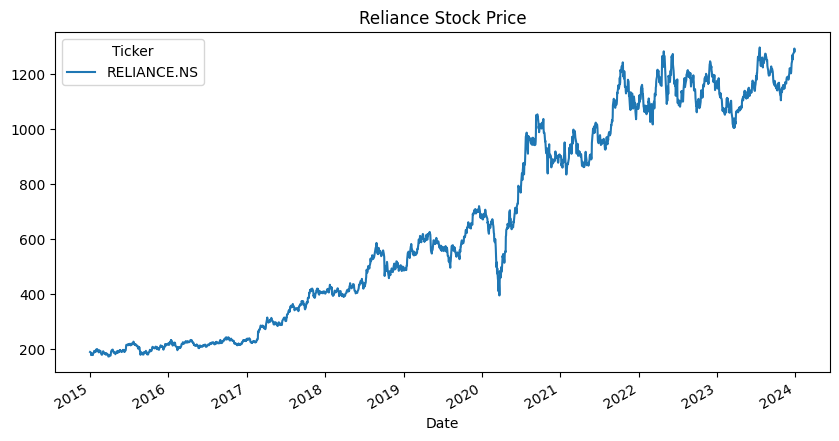

In [4]:
# Price visualization

import matplotlib.pyplot as plt

df['Close'].plot(figsize=(10,5), title="Reliance Stock Price")
plt.show()

In [22]:
# In this graph --- The overall direction is upward Price moved from ₹180 in 2015 to ₹1300+ by 2024.
# This suggests strong long-term growth in the company’s value.

In [ ]:
df.isnull().sum()

Price   Ticker     
Close   RELIANCE.NS    0
High    RELIANCE.NS    0
Low     RELIANCE.NS    0
Open    RELIANCE.NS    0
Volume  RELIANCE.NS    0
dtype: int64

<Axes: >

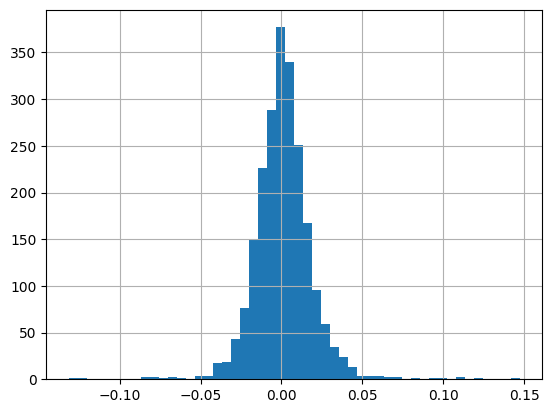

In [ ]:
# Returns distribution 

df['Return'] = df['Close'].pct_change()
df['Return'].hist(bins=50)

<Axes: xlabel='Date'>

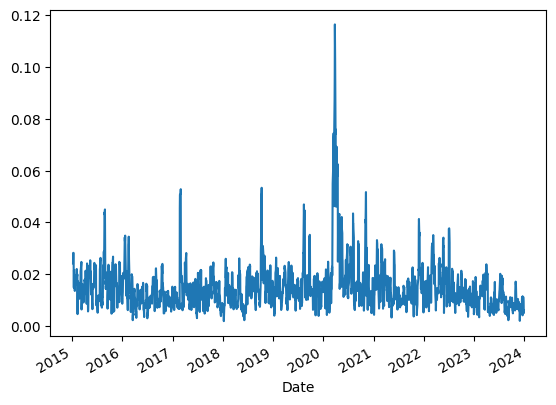

In [ ]:
# Volatility plot (Rolling Std)

df['Return'].rolling(5).std().plot()

<Axes: xlabel='Price-Ticker', ylabel='Price-Ticker'>

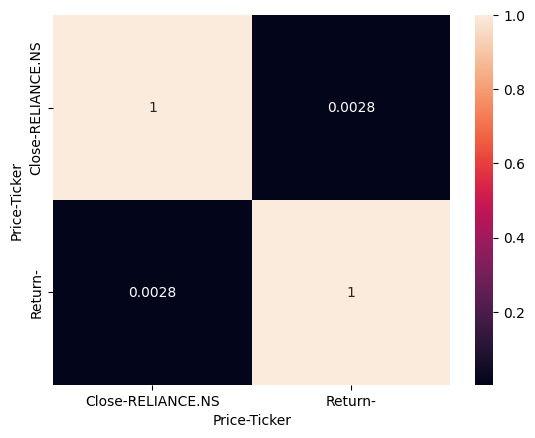

In [18]:
# Correlation

import seaborn as sns
sns.heatmap(df[['Close','Return']].corr(), annot=True)

<Axes: xlabel='Return'>

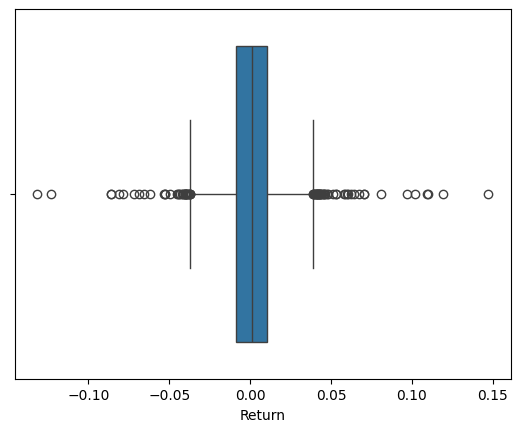

In [ ]:
# Boxplot (Outliers)

import seaborn as sns
sns.boxplot(x=df['Return'])

In [21]:
# The stock shows a strong upward trend but is highly volatile
# Daily returns are centered near zero with fat tails, indicating rare extreme movements
# Volatility spikes during crisis periods (like 2020), showing regime changes
# Returns and price are weakly correlated, so returns are more useful for modeling
# # Presence of many outliers confirms financial data is noisy and unpredictable 

In [36]:
# Feature Engineering

df['Return'] = df['Close'].pct_change()      # Daily return


df['MA5'] = df['Close'].rolling(window=5).mean()      # Moving averages    
df['MA10'] = df['Close'].rolling(window=10).mean()

baseline = (y_test == 1).mean()
print("Baseline:", baseline)


df['Volatility'] = df['Return'].rolling(window=5).std()       # Volatility 

Baseline: 0.5091277890466531


In [37]:
importance = pd.Series(model.feature_importances_, index=features)
print(importance.sort_values(ascending=False))

Volatility    0.263511
Return        0.259790
MA5           0.241563
MA10          0.235136
dtype: float64


In [ ]:
df

Price,Close,High,Low,Open,Volume,Return,MA5,MA10,Volatility
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,,,,
Date,,,,,,,,,
2015-01-01,189.999832,190.877186,189.090381,189.657461,2963643,NaN,NaN,NaN,NaN
2015-01-02,189.496948,191.743828,189.229471,190.042616,7331366,-0.002647,NaN,NaN,NaN
2015-01-05,187.421265,190.641790,187.046782,189.379255,10103941,-0.010954,NaN,NaN,NaN
2015-01-06,178.915207,186.811361,178.037853,186.169401,18627980,-0.045385,NaN,NaN,NaN
2015-01-07,182.809799,183.772746,179.107815,179.129214,20720312,0.021768,185.728610,NaN,NaN
...,...,...,...,...,...,...,...,...,...
2023-12-22,1273.102173,1280.968874,1264.466020,1270.397218,16541784,0.000976,1264.029346,1241.359644,0.011285
2023-12-26,1279.554443,1286.453333,1271.935784,1274.566338,7465664,0.005068,1269.692432,1247.251038,0.010989


In [25]:
# Create target 

df['Target'] = (df['Close'].shift(-1) > df['Close']).astype(int)

In [26]:
df

Price,Close,High,Low,Open,Volume,Return,MA5,MA10,Volatility,Target
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,,,,,
Date,,,,,,,,,,
2015-01-01,189.999832,190.877186,189.090381,189.657461,2963643,NaN,NaN,NaN,NaN,0
2015-01-02,189.496948,191.743828,189.229471,190.042616,7331366,-0.002647,NaN,NaN,NaN,0
2015-01-05,187.421265,190.641790,187.046782,189.379255,10103941,-0.010954,NaN,NaN,NaN,0
2015-01-06,178.915207,186.811361,178.037853,186.169401,18627980,-0.045385,NaN,NaN,NaN,1
2015-01-07,182.809799,183.772746,179.107815,179.129214,20720312,0.021768,185.728610,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...
2023-12-22,1273.102173,1280.968874,1264.466020,1270.397218,16541784,0.000976,1264.029346,1241.359644,0.011285,1
2023-12-26,1279.554443,1286.453333,1271.935784,1274.566338,7465664,0.005068,1269.692432,1247.251038,0.010989,1


In [28]:
# Data cleaning 

df = df.dropna()

In [29]:
df.head()

Price,Close,High,Low,Open,Volume,Return,MA5,MA10,Volatility,Target
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,,,,,
Date,,,,,,,,,,
2015-01-14,178.669144,181.247695,177.866684,180.391739,11380041,-0.009726,181.065811,183.397211,0.014792,1
2015-01-15,184.938965,186.404782,179.749766,179.749766,16927085,0.035092,182.015912,182.891124,0.021539,1
2015-01-16,186.105240,187.239372,182.328348,184.029545,19136963,0.006306,182.418213,182.551953,0.019650,1
2015-01-19,188.234390,189.593203,183.762044,186.212206,13339962,0.011441,183.674319,182.633266,0.018211,1
2015-01-20,193.241730,193.776698,188.063214,188.630295,13361320,0.026602,186.237894,184.065918,0.017552,1


In [ ]:
# Train-Test Split (Time-based)

train = df[df.index < '2022-01-01']
test = df[df.index >= '2022-01-01']

In [31]:
# Define Features

features = ['Return', 'MA5', 'MA10', 'Volatility']

X_train = train[features]
y_train = train['Target']

X_test = test[features]
y_test = test['Target']

In [32]:
# Training Model

from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [33]:
# Evaluation

In [34]:
# Predictions

from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.49898580121703856
              precision    recall  f1-score   support

           0       0.49      0.37      0.42       242
           1       0.51      0.63      0.56       251

    accuracy                           0.50       493
   macro avg       0.50      0.50      0.49       493
weighted avg       0.50      0.50      0.49       493



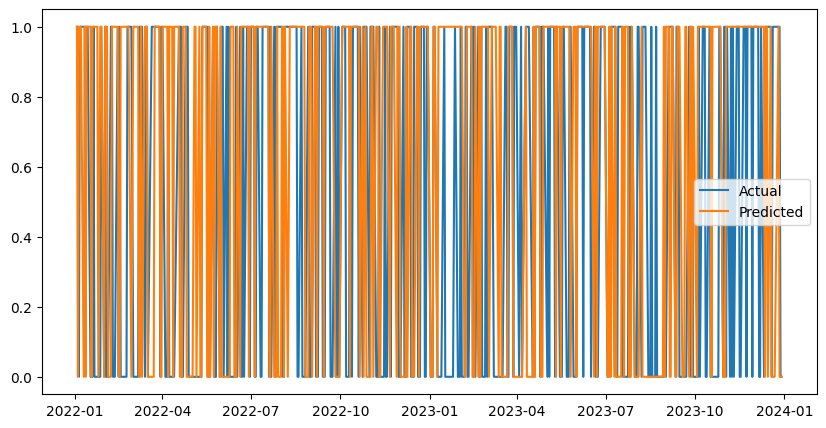

In [35]:
# Visual Comparison

test['Prediction'] = y_pred

plt.figure(figsize=(10,5))
plt.plot(test.index, test['Target'], label='Actual')
plt.plot(test.index, test['Prediction'], label='Predicted')
plt.legend()
plt.show()